In [73]:
import pandas as pd

df = pd.DataFrame()
for i in range(127):
    captions = f'/data3/lihaochen/datasets/CosmicManHQ-1.0/label/laion1B-nolang_{i}_human.parquet'
    df_split = pd.read_parquet(captions, columns=['image_name', 'blip_text'])
    df = pd.concat([df, df_split], ignore_index=True)

df['image_name'] = df['image_name'].apply(lambda x: int(x.split('.')[0]))
df.set_index('image_name', inplace=True)

In [74]:
import os
import datasets
import pandas as pd
import tqdm

dataset_root = '/data3/lihaochen/datasets/BGRelight/imgs'
dataset = []

for img_dir_split in range(5):
    img_dir = os.path.join(dataset_root, '%05d' % img_dir_split)
    img_files = os.listdir(img_dir)
    img_files = sorted(img_files)
    t = len(img_files)
    
    exist = 0
    not_exist = 0

    for i, img_file in tqdm.tqdm(enumerate(img_files)):
        img_path = os.path.join(img_dir, img_file)
        person = f'{img_dir_split}/{img_file}'
        phi = 0
        mask = os.path.join(img_path, 'mask_0.png')
        source = os.path.join(img_path, 'relight_0.png')
        target = os.path.join(img_path, 'img_0.png')
        depth = os.path.join(img_path, 'img_depth_0.npy')
        # lighting = os.path.join(os.path.join(img_dir, img_files[(i+1)%t]), 'refined_0.png')
        lighting = os.path.join(img_path, 'refined_0.png')
        if int(img_file) in df.index:
            caption = df.loc[int(img_file)]['blip_text']
            exist += 1
        else:
            caption = ''
            not_exist += 1
            # print(f'{img_file} not exist')
        dataset.append((person, phi, mask, source, target, depth, caption, lighting))

    print(f'exist: {exist}, not exist: {not_exist}')

dict_dataset = {
    'person': [r[0] for r in dataset],
    'phi': [r[1] for r in dataset],
    'mask': [r[2] for r in dataset],
    'source': [r[3] for r in dataset],
    'target': [r[4] for r in dataset],
    'depth': [r[5] for r in dataset],
    'caption': [r[6] for r in dataset],
    'lighting': [r[7] for r in dataset],
}

ds = datasets.Dataset.from_dict(dict_dataset)

ds.to_parquet('./stage2.parquet')

1073it [00:04, 230.72it/s]


exist: 1068, not exist: 5


1242it [00:04, 254.12it/s]


exist: 1226, not exist: 16


1251it [00:05, 237.47it/s]


...

exist: 1053, not exist: 14


826it [00:02, 320.17it/s]


exist: 819, not exist: 7


Creating parquet from Arrow format: 100%|██████████| 6/6 [00:00<00:00, 318.05ba/s]


2568754

Generating train split: 5459 examples [00:00, 529036.63 examples/s]


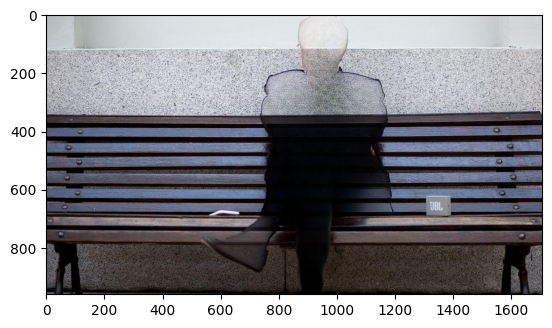

In [75]:
# dataset read test

from datasets import load_dataset
from torchvision import transforms
import cv2
import numpy as np
import matplotlib.pyplot as plt

ds = load_dataset('parquet', data_files='./stage2.parquet')

os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1" 
os.environ["OPENCV_IMGCODECS_USE_OPENEXR"] = "1"

def preprocess_train(examples):
    source = [cv2.imread(source, cv2.IMREAD_UNCHANGED) for source in examples['source']]
    source = [cv2.cvtColor(s, cv2.COLOR_BGR2RGB) for s in source]

    target = [cv2.imread(target, cv2.IMREAD_UNCHANGED) for target in examples['target']]
    target = [cv2.cvtColor(t, cv2.COLOR_BGR2RGB) for t in target]

    mask = [cv2.imread(mask, cv2.IMREAD_UNCHANGED) for mask in examples['mask']]
    mask = [np.where(m > 0, 1, 0).astype(np.uint8) for m in mask]

    depth = [np.load(depth) for depth in examples['depth']]

    lighting = [cv2.imread(lighting, cv2.IMREAD_UNCHANGED) for lighting in examples['lighting']]
    lighting = [cv2.cvtColor(l, cv2.COLOR_BGR2RGB) for l in lighting]
    lighting = [np.roll(l, -int(l.shape[1] * phi / 2), 1) for l, phi in zip(lighting, examples['phi'])]

    examples['source'] = source
    examples['target'] = target
    examples['mask'] = mask
    examples['depth'] = depth
    examples['lighting'] = lighting

    return examples

ds = ds.with_transform(preprocess_train)

# ds['train'][0]['lighting']
plt.imshow(ds['train'][0]['lighting'])
